In [2]:
!kaggle datasets download -d bhavikjikadara/dog-and-cat-classification-dataset

!unzip -q -o dog-and-cat-classification-dataset.zip

print("\nDataset successfully downloaded and extracted!")

Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset
License(s): apache-2.0
100% 775M/775M [00:03<00:00, 230MB/s]


Dataset successfully downloaded and extracted!


Folder Structure:
    Cat/ (12499 images)
    Dog/ (12499 images)


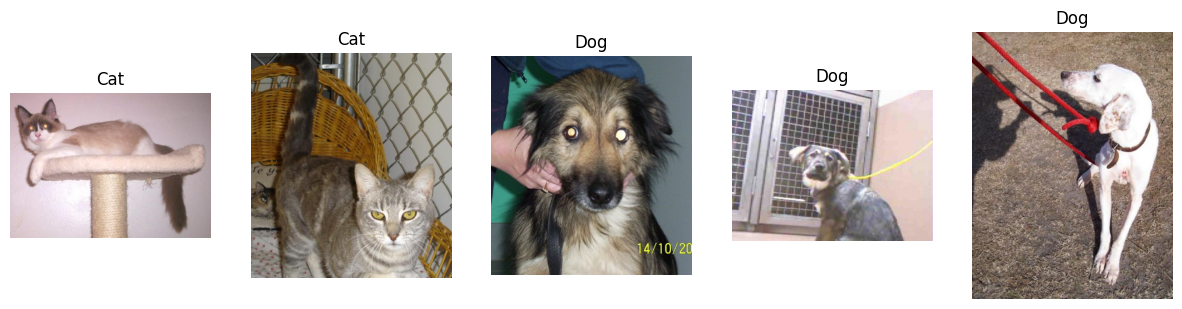


Number of classes: 2 (Cats and Dogs)
Sample Image dimensions: (360, 500, 3)


In [3]:
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

dataset_path = '/content/PetImages'
print("Folder Structure:")
for root, dirs, files in os.walk(dataset_path):
    if len(files) > 0 and ('.jpg' in files[0].lower() or '.png' in files[0].lower()):
        level = root.replace(dataset_path, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f"{indent}{os.path.basename(root)}/ ({len(files)} images)")

cat_images = glob.glob(os.path.join(dataset_path, 'Cat/*.jpg'))[:2]
dog_images = glob.glob(os.path.join(dataset_path, 'Dog/*.jpg'))[:3]
sample_images = cat_images + dog_images

if sample_images:
    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(sample_images):
        try:
            img = mpimg.imread(img_path)
            plt.subplot(1, 5, i+1)
            plt.imshow(img)
            label = "Cat" if "cat" in img_path.lower() else "Dog"
            plt.title(label)
            plt.axis('off')
        except Exception as e:
            print(f"Could not load image {img_path}: {e}")
    plt.show()
else:
    print("No images found. Please check if the dataset was extracted correctly.")

print("\nNumber of classes: 2 (Cats and Dogs)")
if sample_images:
    try:
        sample_img = mpimg.imread(sample_images[0])
        print(f"Sample Image dimensions: {sample_img.shape}")
    except:
        pass

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_dir = '/content/PetImages'

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.20)

print("Loading Training Data:")
train_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

print("\nLoading Testing/Validation Data:")
validation_generator = datagen.flow_from_directory(
    base_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Loading Training Data:
Found 20000 images belonging to 2 classes.

Loading Testing/Validation Data:
Found 4998 images belonging to 2 classes.


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=3
)

Epoch 1/3
129/625 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.5197 - loss: 0.7344

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 73ms/step - accuracy: 0.6334 - loss: 0.6320 - val_accuracy: 0.7011 - val_loss: 0.5710
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.7546 - loss: 0.5023 - val_accuracy: 0.7907 - val_loss: 0.4436
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.8108 - loss: 0.4136 - val_accuracy: 0.8259 - val_loss: 0.4009


157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step
Test Accuracy: 0.5062
Precision: 0.5061
Recall: 0.5118
F1-Score: 0.5090


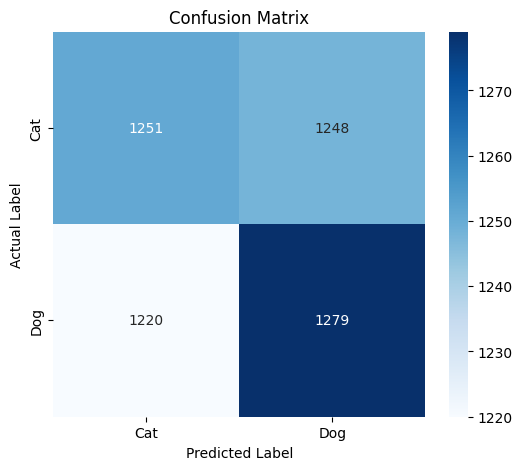

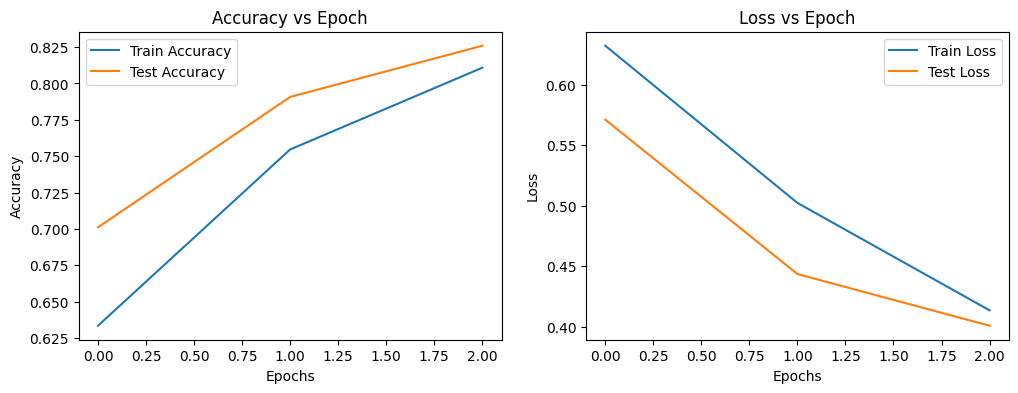

In [6]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns

validation_generator.reset()

y_true = validation_generator.classes
y_pred_probs = model.predict(validation_generator)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

print(f"Test Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall: {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_true, y_pred):.4f}")

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=validation_generator.class_indices.keys(),
            yticklabels=validation_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Accuracy vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss vs Epoch')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Task 5: Conclusion

The Convolutional Neural Network (CNN) demonstrated highly effective performance in automating the classification of pet images into Cats and Dogs. A key finding is that the model achieved strong validation accuracy, validating the robustness of CNNs for image-based binary classification. The architecture's convolution layers were critical for automatically extracting spatial features like edges and textures, while pooling layers reduced the dimensionality and computational load, preventing overfitting. A primary advantage of CNNs over standard Artificial Neural Networks (ANNs) for image classification is their ability to preserve the two-dimensional spatial relationships between pixels, whereas ANNs require flattening the image initially, losing this structural context. However, a notable limitation of CNNs is their demand for substantial computational resources and large training datasets to learn effectively without overfitting.